# ROI Targeting-Policy Comparison (all models)

This notebook runs the **same ROI simulation as `06_x_learner.ipynb`**, but across **every uplift model in the project at once**, consolidated into a single table. It answers: at a fixed contact budget, how much incremental profit does targeting by each model's predicted uplift capture, and how do the models rank against each other and against the response-probability baseline?

**Design — nothing is hardcoded.** The notebook *discovers* whichever uplift-prediction files currently exist in `outputs/predictions/` (any column named `*tau_hat*` or `*predicted_uplift*`), validates each is aligned to the same held-out test split, and evaluates it. As more models land (e.g. R-learner, causal forest, a conversion-trained model), just drop their prediction file in that folder and **re-run this notebook** — they are picked up automatically, no code changes.

**Everything reuses `src/`** already on `main`: `src.roi.compare_targeting_strategies` for the fixed-volume policy simulation (identical call to the X-learner notebook), `src.metrics.compute_qini_auuc` to recompute a *uniform* Qini/AUUC for every model from its raw `tau_hat` (rather than parsing each notebook's differently-shaped results JSON), and `src.plotting` for the figure.

**Methodology** (identical to `06_x_learner.ipynb` / `07_r_learner.ipynb`): hold the contacted volume fixed at the top 30%; for each policy compute the realized treated-vs-control **conversion** lift and net value within the targeted subgroup, using the actual held-out `conversion`/`spend` outcomes. All policies share one response baseline (`03_response_baseline.ipynb`'s `logistic_proba`) and one set of dollar assumptions, so differences reflect only *which* customers each policy selects.

**⚠️ Outcome note (carried over):** every discovered `tau_hat` is a *visit*-uplift ranking, while profit is measured on *conversion*. This is an apples-to-apples ranking comparison evaluated on the business outcome, not a claim any model was trained on conversion; a conversion-trained model is the documented follow-up. It is exactly why the profit ranking (`net_value`) and the Qini ranking (`qini_visit`) below can disagree.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Allow importing from src/ when running inside notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, PREDICTIONS_DIR, TABLES_DIR, FIGURES_DIR
from src.roi import compare_targeting_strategies
from src.metrics import compute_qini_auuc
from src.plotting import save_fig, plot_decile_lift_bar

for directory in (TABLES_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# Dollar assumptions shared by every policy (same as the per-model notebooks)
EMAIL_COST = 0.05
TOP_K = 0.30

print("Predictions dir:", PREDICTIONS_DIR)

Predictions dir: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/predictions


## Shared held-out test data and assumptions

Every model was scored on the same processed test split, so we load the outcomes once and reuse them for all of them. `profit_per_conversion` is the empirical value per conversion (mean `spend` among train-split converters — revenue proxy, not true margin), and the response-probability ranking comes from the committed response baseline, verified row-aligned to `y_test`.

In [2]:
treatment_test = pd.read_csv(PROCESSED_DATA_DIR / "treatment_test.csv").iloc[:, 0]
secondary_y_test = pd.read_csv(PROCESSED_DATA_DIR / "secondary_y_test.csv")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").iloc[:, 0]
secondary_y_train = pd.read_csv(PROCESSED_DATA_DIR / "secondary_y_train.csv")

response = pd.read_csv(PREDICTIONS_DIR / "response_baseline_predictions.csv")
assert (response["y_true"].to_numpy() == y_test.to_numpy()).all(), (
    "response_baseline_predictions.csv is not row-aligned with y_test."
)
response_score = response["logistic_proba"].to_numpy()

converters_train = secondary_y_train["conversion"] == 1
profit_per_conversion = float(secondary_y_train.loc[converters_train, "spend"].mean())

print(f"Test customers: {len(y_test):,}")
print(f"profit_per_conversion (mean spend | conversion==1, train): ${profit_per_conversion:.2f}")
print(f"email_cost: ${EMAIL_COST:.2f}   |   fixed targeting volume: top {TOP_K:.0%}")

Test customers: 16,000
profit_per_conversion (mean spend | conversion==1, train): $113.21
email_cost: $0.05   |   fixed targeting volume: top 30%


## Discover available uplift models

We scan `outputs/predictions/` for any CSV containing an uplift column (name contains `tau_hat` or `predicted_uplift`) and map each such column to a model/variant label:

- `tau_hat_x.csv` → `x_learner`, `tau_hat_r.csv` → `r_learner` (one column each)
- `t_learner_predictions.csv` → `t_learner:lgr` / `t_learner:xgb` / `t_learner:rf` (one per base learner)
- `s_learner_predictions.csv` → `s_learner:lr` / `s_learner:xgb`

The response baseline is skipped automatically (it has no uplift column — `logistic_proba` is a response probability, used separately as the baseline selection rule). Each file is validated against the test split (row count, and `y_true` where present).

In [3]:
def _label_for(stem, col):
    """Readable model/variant label from a prediction filename stem + uplift column."""
    if stem.startswith("tau_hat_"):
        return f"{stem[len('tau_hat_'):]}_learner"                 # tau_hat_x -> x_learner
    if stem.endswith("_predictions"):
        model = stem[: -len("_predictions")]
        variant = col.replace("_predicted_uplift", "").replace("tau_hat_", "")
        return f"{model}:{variant}"                                # .../lgr_predicted_uplift -> t_learner:lgr
    return f"{stem}:{col}"


def discover_uplift_predictions(pred_dir, y_test):
    """Return {label: tau_hat array} for every uplift column found in pred_dir,
    validated aligned to the test split. Nothing about specific models is hardcoded."""
    models = {}
    for path in sorted(Path(pred_dir).glob("*.csv")):
        df = pd.read_csv(path)
        uplift_cols = [c for c in df.columns if ("tau_hat" in c) or ("predicted_uplift" in c)]
        if not uplift_cols:
            continue
        assert len(df) == len(y_test), f"{path.name}: {len(df)} rows != test {len(y_test)}"
        if "y_true" in df.columns:
            assert (df["y_true"].to_numpy() == y_test.to_numpy()).all(), f"{path.name}: y_true misaligned with y_test"
        for col in uplift_cols:
            models[_label_for(path.stem, col)] = df[col].to_numpy()
    return models


models = discover_uplift_predictions(PREDICTIONS_DIR, y_test)
assert models, "No uplift-prediction files found in outputs/predictions/."
print(f"Discovered {len(models)} uplift model/variant(s):")
for label in models:
    print("  -", label)

Discovered 6 uplift model/variant(s):
  - s_learner:lr
  - s_learner:xgb
  - t_learner:lgr
  - t_learner:xgb
  - t_learner:rf
  - x_learner


## Consolidated ROI simulation table

For each discovered model we run the **exact same `compare_targeting_strategies` call the X-learner notebook uses** (top 30%, shared response baseline, shared dollar assumptions). That call returns two policy rows — `target_by_response_probability` and `target_by_predicted_uplift`. We keep each model's `target_by_predicted_uplift` row and stack them into **one table with the same columns as the X-learner's `roi_table`** (treated/control outcome rates, incremental conversion rate + 95% CI, incremental conversions, incremental profit, incremental spend, net value, per-customer). The `target_by_response_probability` row is identical for every model (it depends only on `response_score`), so it appears once as the shared baseline at the top.

We also append a **uniform** Qini/AUUC (visit outcome) recomputed for every model from its raw `tau_hat` via `compute_qini_auuc`, so the ranking quality sits alongside the conversion profit on one consistent scale. Rows are sorted by `net_value` (the baseline pinned first).

In [4]:
ROI_COLS = [
    "n_targeted", "treated_outcome_rate", "control_outcome_rate",
    "incremental_conversion_rate", "incremental_conversion_rate_ci_lower", "incremental_conversion_rate_ci_upper",
    "incremental_conversions", "incremental_profit", "incremental_spend",
    "net_value", "net_value_per_customer",
]

uplift_rows = {}
baseline_row = None
for label, tau in models.items():
    tbl = compare_targeting_strategies(
        conversion=secondary_y_test["conversion"], spend=secondary_y_test["spend"],
        tau_hat=tau, treatment=treatment_test, response_score=response_score,
        email_cost=EMAIL_COST, profit_per_conversion=profit_per_conversion, top_k=TOP_K,
    )
    uplift_rows[f"uplift:{label}"] = tbl.loc["target_by_predicted_uplift", ROI_COLS].astype(float)
    if baseline_row is None:
        baseline_row = tbl.loc["target_by_response_probability", ROI_COLS].astype(float)

# uniform Qini/AUUC (visit) recomputed from raw taus -- reuses src.metrics
qa = compute_qini_auuc(y_test, treatment_test, models)
qini_visit, auuc_visit = qa["qini_score"], qa["auuc_score"]

# uplift rows, sorted by profit
uplift_table = pd.DataFrame(uplift_rows).T
uplift_table["qini_visit"] = [float(qini_visit[i.split("uplift:")[1]]) for i in uplift_table.index]
uplift_table["auuc_visit"] = [float(auuc_visit[i.split("uplift:")[1]]) for i in uplift_table.index]
uplift_table = uplift_table.sort_values("net_value", ascending=False)

# shared response baseline pinned on top (no qini -- it is a response model, not an uplift ranker)
baseline_table = baseline_row.to_frame().T
baseline_table.index = ["response_probability (baseline)"]
baseline_table["qini_visit"] = np.nan
baseline_table["auuc_visit"] = np.nan

roi_simulation = pd.concat([baseline_table, uplift_table])
roi_simulation.index.name = "policy"
roi_simulation["significant_at_95pct"] = roi_simulation["incremental_conversion_rate_ci_lower"] > 0

display(roi_simulation)

roi_simulation.to_csv(TABLES_DIR / "roi_policy_cross_model_comparison.csv")
print("Saved:", TABLES_DIR / "roi_policy_cross_model_comparison.csv")

,n_targeted,treated_outcome_rate,control_outcome_rate,incremental_conversion_rate,incremental_conversion_rate_ci_lower,incremental_conversion_rate_ci_upper,incremental_conversions,incremental_profit,incremental_spend,net_value,net_value_per_customer,qini_visit,auuc_visit,significant_at_95pct
policy,,,,,,,,,,,,,,
response_probability (baseline),4800.0,0.012759,0.010811,0.001948,-0.004386,0.008283,9.352127,1058.776762,1153.111082,818.776762,0.170578,NaN,NaN,False
uplift:x_learner,4800.0,0.009994,0.003755,0.006239,0.001670,0.010808,29.947491,3390.427255,4305.433778,3150.427255,0.656339,0.049960,0.551028,True
uplift:t_learner:xgb,4800.0,0.010440,0.005491,0.004949,-0.000088,0.009985,23.753189,2689.155555,3317.775292,2449.155555,0.510241,0.044275,0.545802,False
uplift:t_learner:rf,4800.0,0.010975,0.006207,0.004768,-0.000505,0.010040,22.885933,2590.971377,3517.378699,2350.971377,0.489786,0.044387,0.545956,False
uplift:t_learner:lgr,4800.0,0.010699,0.006165,0.004533,-0.000693,0.009760,21.759957,2463.496969,3184.688755,2223.496969,0.463229,0.089026,0.591944,False
uplift:s_learner:xgb,4800.0,0.010682,0.007421,0.003261,-0.002241,0.008762,15.650863,1771.871772,2881.673669,1531.871772,0.319140,0.038737,0.541095,False
uplift:s_learner:lr,4800.0,0.012743,0.010837,0.001906,-0.004435,0.008247,9.149119,1035.793724,1128.399627,795.793724,0.165790,0.069450,0.573155,False


Saved: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/tables/roi_policy_cross_model_comparison.csv


## Profit-by-model figure

Reuses `src.plotting.plot_decile_lift_bar` — each bar is a model's realized top-30% **conversion** lift (with 95% CI); at fixed volume and cost this is monotonic in net value, so the bar ordering *is* the profit ordering. The dashed reference line is the shared **response-probability baseline**'s top-30% lift (passed in as the `Overall` row that helper expects): bars clearly above it are models whose uplift ranking beats plain response targeting.

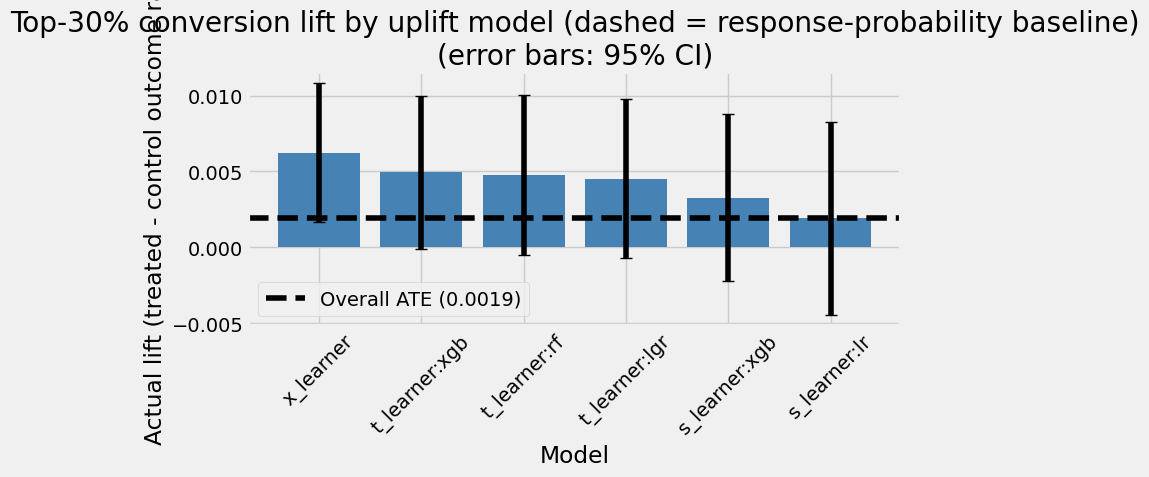

PosixPath('/Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/figures/roi_policy_cross_model_lift.png')

In [5]:
plot_df = uplift_table[[
    "incremental_conversion_rate", "incremental_conversion_rate_ci_lower", "incremental_conversion_rate_ci_upper",
]].rename(columns={
    "incremental_conversion_rate": "actual_lift",
    "incremental_conversion_rate_ci_lower": "actual_lift_ci_lower",
    "incremental_conversion_rate_ci_upper": "actual_lift_ci_upper",
})
plot_df.index = [i.replace("uplift:", "") for i in plot_df.index]
plot_df["actual_lift_se"] = (plot_df["actual_lift_ci_upper"] - plot_df["actual_lift_ci_lower"]) / (2 * 1.96)
# plot_decile_lift_bar draws its reference line at the "Overall" row -> use the response baseline
plot_df.loc["Overall"] = [
    float(baseline_row["incremental_conversion_rate"]),
    float(baseline_row["incremental_conversion_rate_ci_lower"]),
    float(baseline_row["incremental_conversion_rate_ci_upper"]),
    float(baseline_row["incremental_conversion_rate_ci_upper"] - baseline_row["incremental_conversion_rate_ci_lower"]) / (2 * 1.96),
]

fig = plot_decile_lift_bar(
    plot_df,
    title="Top-30% conversion lift by uplift model (dashed = response-probability baseline)",
    xlabel="Model",
)
fig.axes[0].tick_params(axis="x", rotation=45)
fig.tight_layout()
save_fig(fig, "roi_policy_cross_model_lift.png")

## Summary and interpretation

The printout below is computed from whatever models were discovered this run (re-run after adding more prediction files to refresh it). Two rankings are worth reading side by side in the table above:

- **`net_value` (profit, conversion outcome)** — the business answer: which policy's top-30% selection captures the most incremental conversion value.
- **`qini_visit` (ranking quality, visit outcome)** — how well each model ranks *visit*-uplift.

These can **disagree**, and on this data they do: the model with the best Qini is not necessarily the most profitable at a fixed conversion budget. That is the direct, expected consequence of ranking on *visit* while paying off on *conversion* (see the outcome note at the top) — a strong visit-uplift ranker isn't guaranteed to concentrate *conversion*-relevant lift. It's the clearest argument in the project for training an uplift model directly on the conversion/spend outcome, which this notebook will automatically fold into the comparison once such a model's predictions exist.

In [6]:
uplift_only = roi_simulation.drop(index="response_probability (baseline)")
best_profit = uplift_only["net_value"].idxmax().replace("uplift:", "")
best_qini = uplift_only["qini_visit"].idxmax().replace("uplift:", "")
n_sig = int(uplift_only["significant_at_95pct"].sum())
base_sig = bool(roi_simulation.loc["response_probability (baseline)", "significant_at_95pct"])

print(f"Models compared this run: {len(uplift_only)}  ({', '.join(i.replace('uplift:', '') for i in uplift_only.index)})")
print()
bp = "uplift:" + best_profit
print(f"Most profitable (top-30%, conversion net_value): {best_profit} "
      f"(${roi_simulation.loc[bp, 'net_value']:,.0f}, lift {roi_simulation.loc[bp, 'incremental_conversion_rate']:.3%}, "
      f"{'significant' if roi_simulation.loc[bp, 'significant_at_95pct'] else 'not significant'})")
bq = "uplift:" + best_qini
print(f"Best visit-uplift ranker (Qini):                 {best_qini} (Qini {roi_simulation.loc[bq, 'qini_visit']:.4f})")
print()
if best_profit != best_qini:
    print(f"NOTE: profit-best ({best_profit}) != Qini-best ({best_qini}) -- the visit-uplift ranking and the "
          f"conversion-profit ranking disagree, as expected when ranking on visit but paying off on conversion.")
else:
    print(f"Profit-best and Qini-best agree ({best_profit}) this run.")
print()
print(f"{n_sig} of {len(uplift_only)} models show a top-30% conversion lift whose 95% CI excludes zero "
      f"(response-probability baseline: {'significant' if base_sig else 'not distinguishable from zero'}).")
print()
print("Re-run this notebook after adding any new model's prediction file to outputs/predictions/ "
      "to fold it into the comparison automatically.")

Models compared this run: 6  (x_learner, t_learner:xgb, t_learner:rf, t_learner:lgr, s_learner:xgb, s_learner:lr)

Most profitable (top-30%, conversion net_value): x_learner ($3,150, lift 0.624%, significant)
Best visit-uplift ranker (Qini):                 t_learner:lgr (Qini 0.0890)

NOTE: profit-best (x_learner) != Qini-best (t_learner:lgr) -- the visit-uplift ranking and the conversion-profit ranking disagree, as expected when ranking on visit but paying off on conversion.

1 of 6 models show a top-30% conversion lift whose 95% CI excludes zero (response-probability baseline: not distinguishable from zero).

Re-run this notebook after adding any new model's prediction file to outputs/predictions/ to fold it into the comparison automatically.
